# Kapitel 12 - Lösungen

In [1]:
from PIL import Image
from IPython.display import display # Für Jupyter 

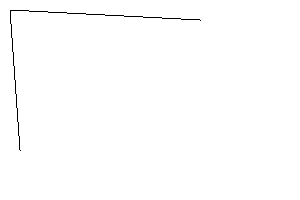

In [2]:
# Aufgabe 1
def zeichneLinie(img,x1,y1,x2,y2,farbe):
    if x2<x1: # ggf tauschen
        [x2,x1]=[x1,x2]
    if y2<y1: # ggf tauschen
        [y2,y1]=[y1,y2]
    if y2-y1<=x2-x1:  # Flach
        m=(y2-y1)/(x2-x1)
        b=y1-m*x1
        for x in range(x1,x2+1):
            img.putpixel((x,int(m*x+b)),farbe)
    else:
        m=(x2-x1)/(y2-y1)
        b=x1-m*y1
        for y in range(y1,y2+1):
            img.putpixel((int(m*y+b),y),farbe)
img1 = Image.new('L', (300, 200), color=255)
zeichneLinie(img1,10,10,200,20,0)
zeichneLinie(img1,10,10,20,150,0)
display(img1)

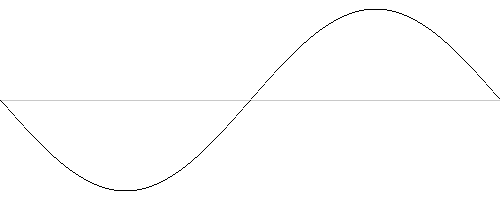

In [3]:
# Aufgabe 2
import math
b=500; h=200;
img2 = Image.new('L', (b, h), color=255)
for xi in range(b):
    img2.putpixel((xi,h//2),200) # Achse
    x=(xi-xi/2)/b*4*math.pi
    y=math.sin(x)
    img2.putpixel((xi,int(h/2+h/2.2*y)),0) # Graph
display(img2)

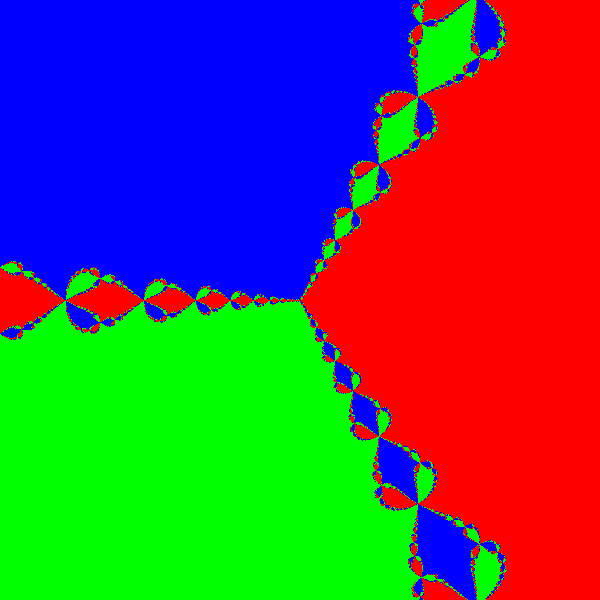

In [4]:
# Aufgabe 3
# Die Julia-Mengen gibt an, gegen welche Lösung von z^3-1=0 die Newton-Iteration konvergiert 
n=600;
img3= Image.new('RGB', (n,n), color=(255,255,255))
def p(z): return z**3-1 # Das Polynom
def dp(z): return 3*z**2 # Ableitung
# Nullstelen von p sind z1,z2,z3
z1=complex(1,0)
z2=complex(-1/2,math.sqrt(3)/2)
z3=complex(-1/2,-math.sqrt(3)/2)
def newton(z,iter=50):
    for i in range(iter):
        if abs(dp(z))>1e-7:
            z=z-p(z)/dp(z)
        else: 
            return "Fail"
    return z
for ix in range(n):
    for iy in range(n):
        z=newton(complex((ix-n/2)/(n/100),(iy-n/2)/(n/100)))
        if z=="Fail":
            img3.putpixel((ix,iy),(0,0,0))
            continue
        if abs(z-z1)<abs(z-z2) and abs(z-z1)<abs(z-z3):
            img3.putpixel((ix,iy),(255,0,0)) 
        if abs(z-z2)<abs(z-z1) and abs(z-z2)<abs(z-z3):
            img3.putpixel((ix,iy),(0,255,0)) 
        if abs(z-z3)<abs(z-z2) and abs(z-z3)<abs(z-z1):
            img3.putpixel((ix,iy),(0,0,255)) 
display(img3)

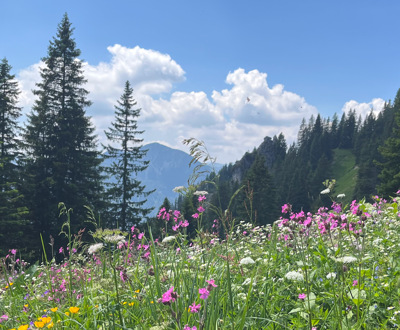

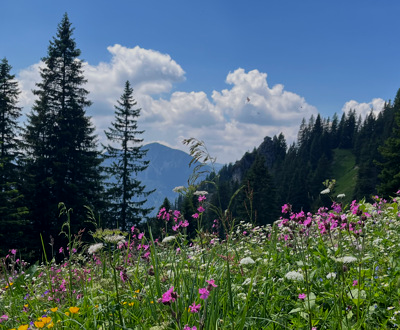

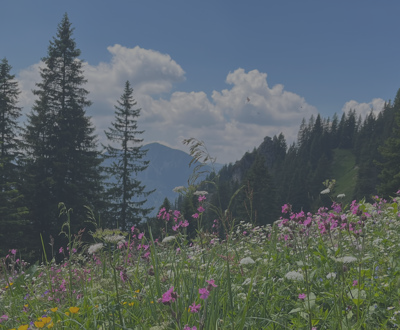

In [5]:
# Aufgabe 4
bild0=Image.open("foto.jpg")
display(bild0)
bild=Image.open("foto.jpg")
for x in range(bild.size[0]):
    for y in range(bild.size[1]):
        (r,g,b)=bild.getpixel((x,y))
        bild.putpixel((x,y),(r-40,g-40,b-40))
display(bild) # Dunkler
def k(x):# Geringerer Kontrast
    return int(30+0.5*x)
for x in range(bild.size[0]):
    for y in range(bild.size[1]):
        (r,g,b)=bild0.getpixel((x,y))
        bild.putpixel((x,y),(k(r),k(g),k(b)))
display(bild) 

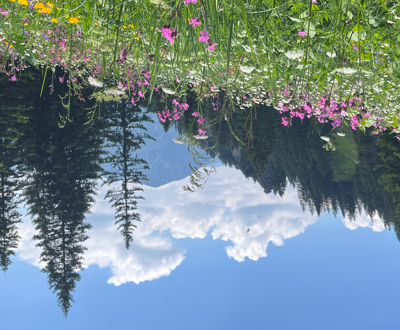

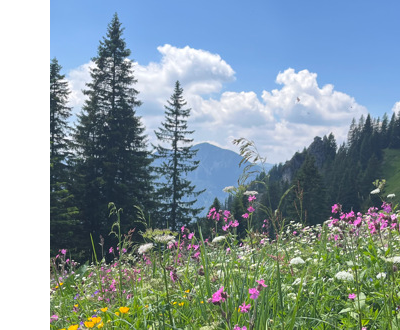

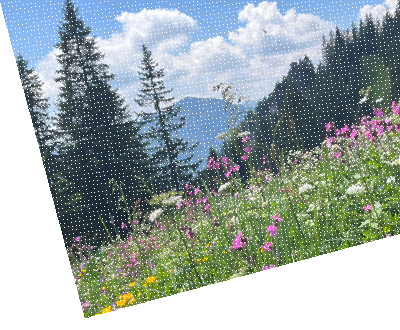

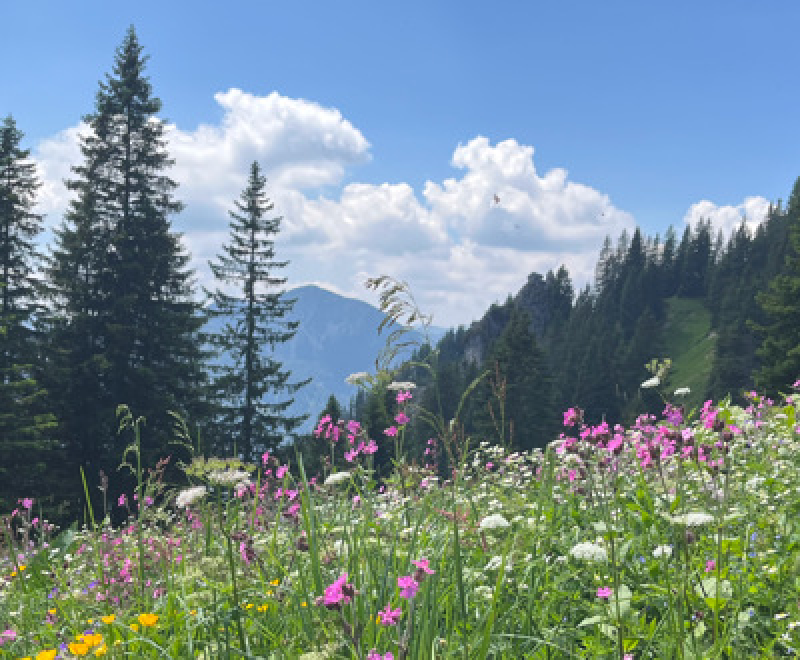

In [6]:
# Aufgabe 4
bild0=Image.open("foto.jpg")
bild=Image.open("foto.jpg")
for x in range(bild.size[0]):
    for y in range(bild.size[1]):
        bild.putpixel((x,bild.size[1]-y-1),bild0.getpixel((x,y)))
display(bild) # Gespiegelt 
bild = Image.new('RGB', bild0.size, color=(255,255,255))
for x in range(bild.size[0]-50):
    for y in range(bild.size[1]):
        bild.putpixel((x+50,y),bild0.getpixel((x,y)))
display(bild) # verschoben 
import math
alpha=15/180*math.pi
bild = Image.new('RGB', bild0.size, color=(255,255,255))
for x in range(bild.size[0]):
    for y in range(bild.size[1]):
        x1=int(x*math.cos(alpha)+y*math.sin(alpha))
        y1=int(-x*math.sin(alpha)+y*math.cos(alpha))
        if x1>=0 and x1<bild.size[0] and y1>=0 and y1<bild.size[1]: 
            bild.putpixel((x1,y1),bild0.getpixel((x,y)))
display(bild) # gedreht 
bild = Image.new('RGB', (bild0.size[0]*2,bild0.size[1]*2), color=(255,255,255))
for x in range(bild0.size[0]):
    for y in range(bild0.size[1]):
        bild.putpixel((2*x,2*y),bild0.getpixel((x,y)))
        bild.putpixel((2*x+1,2*y),bild0.getpixel((x,y)))
        bild.putpixel((2*x,2*y+1),bild0.getpixel((x,y)))
        bild.putpixel((2*x+1,2*y+1),bild0.getpixel((x,y)))
display(bild) # gedreht 
